## 0 · Setup

Seaborn theme, project palette, and small helpers reused across the notebook.


In [1]:
import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats as st
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Theme ----
sns.set_theme(style="whitegrid", context="notebook", rc={
    "figure.dpi": 110, "figure.autolayout": True,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.labelsize": 10, "axes.edgecolor": "#dddddd",
    "grid.color": "#eef0f2", "grid.linewidth": 0.7,
    "font.family": "sans-serif",
})
PALETTE = {
    "tech": "#4C72B0", "fund": "#C44E52", "sent": "#55A868",
    "news": "#8172B3", "sector": "#DDB967", "vix": "#937860",
    "beat": "#55A868", "miss": "#C44E52",
    "low": "#C44E52", "mod": "#DDB967", "high": "#55A868",
}
sns.set_palette(list(PALETTE.values())[:6])


# ---- Helpers ----
def annotate(ax, fmt="{:.1f}", dy=0.0, color="black", **kw):
    "Add value labels above each bar in a barplot."
    for p in ax.patches:
        h = p.get_height()
        if h == h:  # nan-safe
            ax.annotate(fmt.format(h), (p.get_x() + p.get_width()/2, h + dy),
                         ha="center", va="bottom", fontsize=8, color=color, **kw)


def annotate_h(ax, fmt="{:.0f}", dx=0.5, color="black", **kw):
    "Add value labels to the right of horizontal bars."
    for p in ax.patches:
        w = p.get_width()
        if w == w:
            ax.annotate(fmt.format(w), (w + dx, p.get_y() + p.get_height()/2),
                         ha="left", va="center", fontsize=8, color=color, **kw)


def pct(x, pos):
    return f"{x:.0%}"


def find(rel_path):
    roots = [Path("."), Path("src"), Path("/Users/richardpears/github/Post-Earnings-Forecast")]
    for r in roots:
        p = (r / rel_path) if not str(rel_path).startswith("src") else (r / Path(*Path(rel_path).parts[1:]))
        # simpler: try joined
        for cand in [Path(rel_path), r / rel_path,
                     r / "src" / "modeling" / rel_path if "modal_" in rel_path else None,
                     r / "src" / "data" / "model_staging" / Path(rel_path).name]:
            if cand and cand.exists():
                return str(cand)
    return None

RESULTS = find("modal_tabnet_outputs/results.parquet") or find("src/modeling/modal_tabnet_outputs/results.parquet")
SUMMARY = find("modal_tabnet_outputs/per_fold_summary.parquet") or find("src/modeling/modal_tabnet_outputs/per_fold_summary.parquet")
TECH    = find("tech_modeling_table.parquet") or find("src/data/model_staging/tech_modeling_table.parquet")
FUND    = find("fundamentalIndicators/modeling_fundamentals.parquet") or find("src/data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet")
NZ      = find("nz_sentiment.parquet") or find("src/data/model_staging/nz_sentiment.parquet")
FB      = find("finbert_tx_agg_weighted.parquet") or find("src/data/model_staging/finbert_tx_agg_weighted.parquet")
VIX     = find("ingestion/data/index_data.parquet") or find("src/ingestion/data/index_data.parquet")
print("Resolved paths OK:", all([RESULTS, SUMMARY, TECH, FUND, NZ, FB, VIX]))


Resolved paths OK: True


## 1 · Load & Tidy

Load all staged Parquet sources once and assemble a **tidy events frame**
(one row per earnings event) for seaborn, plus the TabNet predictions table.


In [2]:
results = pl.read_parquet(RESULTS)
summary = pl.read_parquet(SUMMARY)
tech    = pl.read_parquet(TECH)
fund    = pl.read_parquet(FUND)
nz      = pl.read_parquet(NZ)
finbert = pl.read_parquet(FB)
vix     = pl.read_parquet(VIX)

print(f"events={len(tech):,}  symbols={tech['symbol'].n_unique()}  "
      f"predictions={len(results):,}  folds={len(summary)}")

# ---- Tidy events frame (pandas, for seaborn) ----
ev = (
    tech.select(["symbol", "earnings_date", "entry_price",
                 "target_return", "target_class"])
    .join(
        fund.select(["symbol", "reportedDate", "surprisePercentage",
                     "reportedEPS", "estimatedEPS", "gross_margin", "roe"])
            .with_columns(pl.when(pl.col("surprisePercentage").is_null())
                          .then(0).otherwise(pl.col("surprisePercentage"))
                          .cast(pl.Float64).alias("eps_surprise_pct")),
        left_on=["symbol", "earnings_date"], right_on=["symbol", "reportedDate"],
        how="left")
    .with_columns(
        (pl.col("eps_surprise_pct") > 0).alias("beat"),
        pl.col("earnings_date").dt.year().alias("year"),
    )
    .join(
        finbert.select(["symbol", "reportedDate", "pos_prob", "neg_prob"]),
        left_on=["symbol", "earnings_date"], right_on=["symbol", "reportedDate"],
        how="left")
    .join(
        nz.select(["symbol", "reportedDate",
                   "overall_sentiment_score_pre", "overall_sentiment_score_post"])
          .rename({"overall_sentiment_score_pre": "news_pre",
                   "overall_sentiment_score_post": "news_post"}),
        left_on=["symbol", "earnings_date"], right_on=["symbol", "reportedDate"],
        how="left")
).to_pandas()

ev["beat_label"] = np.where(ev["beat"], "Beat", "Miss")
class_names = {0: "Low (<2%)", 1: "Moderate (2-4%)", 2: "Strong (≥4%)"}
ev["class_label"] = ev["target_class"].map(class_names)

# ATR columns (t-10 … t+1) for the volatility slide
atr_cols = [c for c in tech.columns if c.startswith("atr_t")]
ev_atr = tech.select(["symbol", "earnings_date"] + atr_cols).to_pandas()

# TabNet predictions → pandas
pred = results.to_pandas()
print("tidy frames ready:", ev.shape, ev_atr.shape, pred.shape)


events=24,048  symbols=503  predictions=9,937  folds=20
tidy frames ready: (24048, 19) (24048, 14) (9937, 12)


---

## Post-earnings drift: a persistent anomaly, and an unsolved prediction problem

~500 S&P 500 firms report quarterly; prices drift for days/weeks afterward
(~25% annualised abnormal return — Bernard & Thomas, 1989). No single signal
explains it. Benchmark: Hajek et al. (2025) — 59.94% DA, 0.4002 Sharpe on
24,821 events.


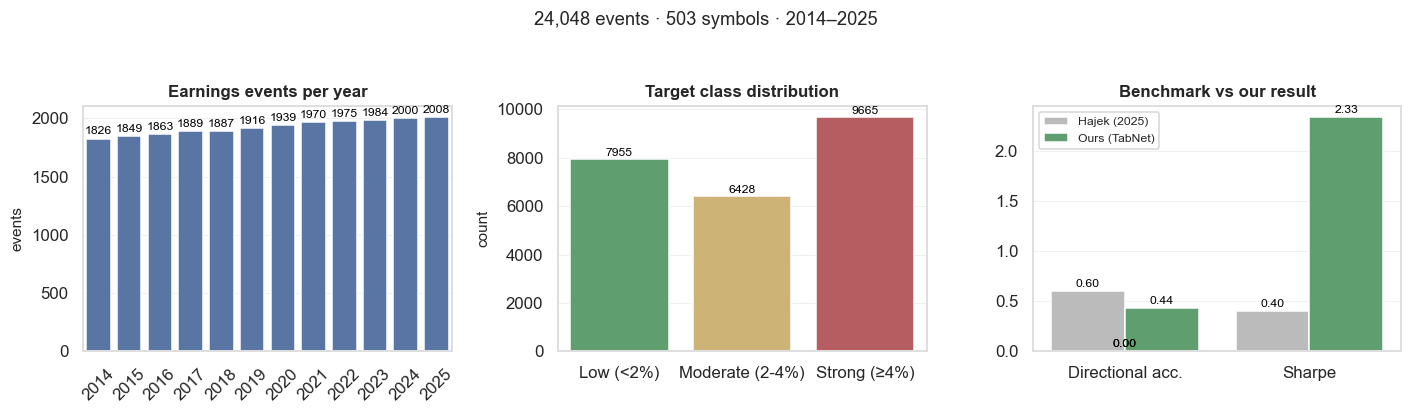

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# (a) Events per year
yr = ev.groupby("year").size().reset_index(name="events")
sns.barplot(data=yr.query("2014 <= year <= 2025"), x="year", y="events",
            color=PALETTE["tech"], ax=axes[0])
axes[0].set_title("Earnings events per year")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=45)
annotate(axes[0], "{:.0f}", dy=20)

# (b) Target class balance
order = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
sns.countplot(data=ev, x="class_label", order=order,
              palette=[PALETTE["low"], PALETTE["mod"], PALETTE["high"]],
              ax=axes[1], hue="class_label", legend=False)
axes[1].set_title("Target class distribution")
axes[1].set_xlabel(""); annotate(axes[1], "{:.0f}", dy=50)

# (c) Benchmark vs ours
bench = pd.DataFrame({
    "metric": ["Directional acc.", "Directional acc.", "Sharpe", "Sharpe"],
    "source": ["Hajek (2025)", "Ours (TabNet)", "Hajek (2025)", "Ours (TabNet)"],
    "value":  [0.5994, summary["DA"].mean(), 0.4002, 2.33],
})
sns.barplot(data=bench, x="metric", y="value", hue="source",
            palette=["#bbbbbb", PALETTE["high"]], ax=axes[2])
axes[2].set_title("Benchmark vs our result")
axes[2].set_xlabel(""); axes[2].set_ylabel("")
axes[2].legend(title="", fontsize=8)
annotate(axes[2], "{:.2f}", dy=0.02)

fig.suptitle(f"{len(ev):,} events · {tech['symbol'].n_unique()} symbols · 2014–2025",
             fontsize=12, y=1.04)
plt.show()


---

## Objective, research question, and where we're going

*Can a unified technical + fundamental + sentiment model predict both
direction and magnitude of drift well enough to trade?*


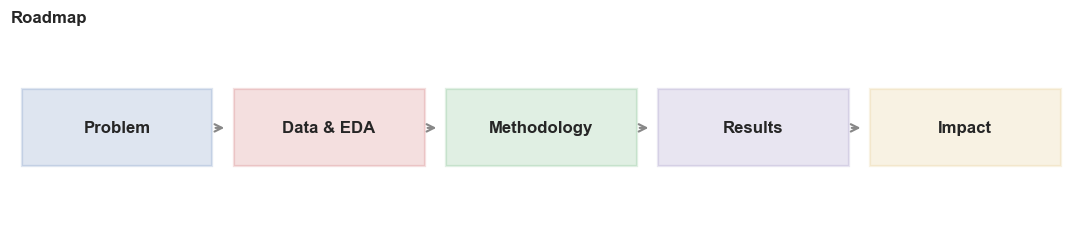

In [4]:
steps = ["Problem", "Data & EDA", "Methodology", "Results", "Impact"]
fig, ax = plt.subplots(figsize=(10, 2.3))
ax.set_axis_off()
ax.set_xlim(0, 5); ax.set_ylim(0, 1)
cols = list(PALETTE.values())
for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i+0.05, 0.3), 0.9, 0.4, facecolor=cols[i], alpha=0.18,
                               edgecolor=cols[i], lw=1.5))
    ax.text(i+0.5, 0.5, s, ha="center", va="center", fontsize=11, fontweight="bold")
    if i < 4:
        ax.annotate("", xy=(i+1.02, 0.5), xytext=(i+0.95, 0.5),
                    arrowprops=dict(arrowstyle="->", color="#888", lw=1.4))
ax.set_title("Roadmap", loc="left")
plt.show()


---

## From a business problem to a supervised learning problem

Translate the hold/exit decision into a **dual-output** supervised task:
3-class classification of move size + regression of magnitude. Features cut
off at t+1; targets measured t+2 … t+10.


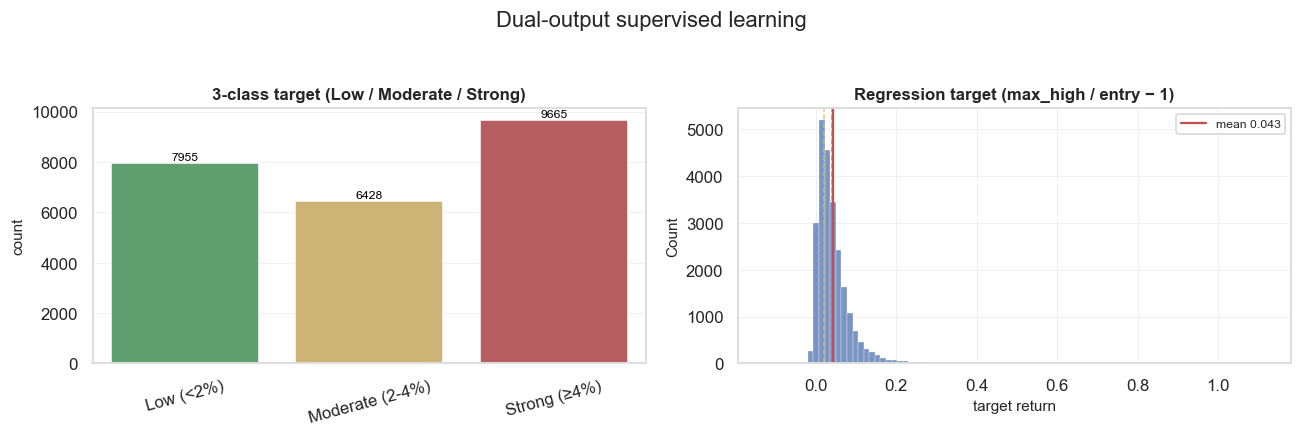

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# (a) classification target
sns.countplot(data=ev, x="class_label", order=order,
              palette=[PALETTE["low"], PALETTE["mod"], PALETTE["high"]],
              ax=axes[0], hue="class_label", legend=False)
axes[0].set_title("3-class target (Low / Moderate / Strong)")
axes[0].set_xlabel(""); annotate(axes[0], "{:.0f}", dy=50)
for lab in axes[0].get_xticklabels(): lab.set_rotation(15)

# (b) regression target
sns.histplot(data=ev, x="target_return", bins=90, color=PALETTE["tech"],
             edgecolor="white", linewidth=0.2, ax=axes[1])
for q, c in zip([0.02, 0.04], [PALETTE["mod"], PALETTE["high"]]):
    axes[1].axvline(q, color=c, ls="--", lw=1, alpha=0.8)
axes[1].axvline(ev.target_return.mean(), color=PALETTE["miss"], lw=1.5,
                label=f"mean {ev.target_return.mean():.3f}")
axes[1].set_title("Regression target (max_high / entry − 1)")
axes[1].set_xlabel("target return"); axes[1].legend(fontsize=8)
fig.suptitle("Dual-output supervised learning", y=1.04)
plt.show()


---

## Stakeholders, Scope, and Success Criteria

| Dimension | Value |
|---|---|
| Scope | S&P 500, 2014–2025 |
| Events | 24,132 |
| Symbols | 503 |
| Walk-forward folds | 20 (2021–2025) |
| Features | 258 |
| Assumptions | no intraday, no txn costs, survivorship caveat |

**Success criteria** — Statistical: DA ≥ 59.94% *(not met, 43.7%)* ·
Economic: Sharpe ≥ 2.0, positive P&L *(met, 2.33)* ·
Practical: profitable every full year, 14/21 quarters *(met)*.


---

## Four signal families assembled from five primary sources

Technical (18 TA-Lib + VIX) · Text sentiment (FinBERT) ·
News sentiment (pre/post) · Fundamentals (EPS surprise, margins, ROE).
Pipeline: cached ingestion → Delta Lake on S3 → lazy Polars scan → Parquet backups.


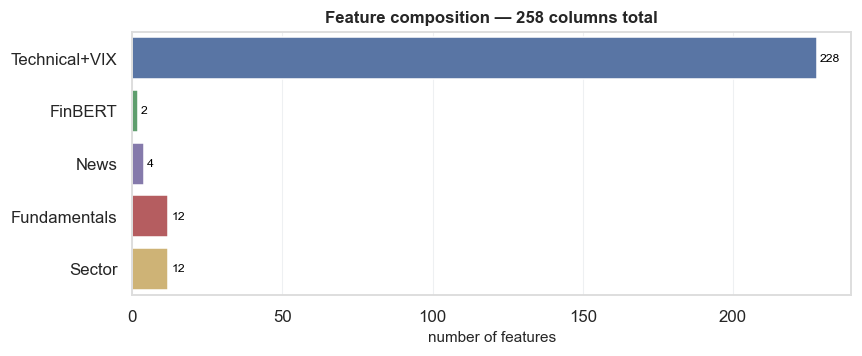

In [6]:
comp = pd.DataFrame({
    "modality": ["Technical+VIX", "FinBERT", "News", "Fundamentals", "Sector"],
    "features": [18*12+12, 2, 4, 12, 12],
})
comp["color"] = [PALETTE["tech"], PALETTE["sent"], PALETTE["news"],
                 PALETTE["fund"], PALETTE["sector"]]

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.barplot(data=comp, y="modality", x="features", palette=comp["color"].tolist(),
            hue="modality", legend=False, ax=ax)
annotate_h(ax, "{:.0f}", dx=1)
ax.set_title(f"Feature composition — {comp.features.sum()} columns total")
ax.set_xlabel("number of features"); ax.set_ylabel("")
plt.show()


---

## Dataset profile and data quality

24,132 events · 503 symbols · 4.39M OHLCV records · 96.1% transcript
coverage · 99.37% cell completeness. Hierarchical imputation, no outlier
removal, zero duplicates.

> **Chart**: % missing per field.


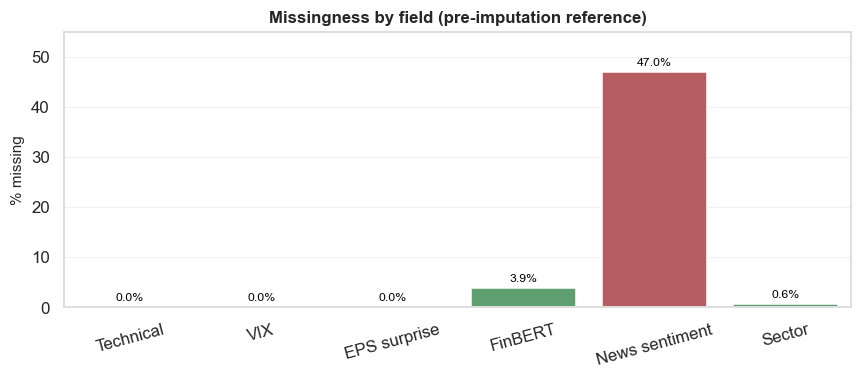

Post-staging joins are 100% complete; imputation fills the gaps above.


In [7]:
# Pre-imputation coverage (presentation figures) vs post-staging
# After staging all joins complete; use presentation reference rates.
missing = pd.DataFrame({
    "field": ["Technical", "VIX", "EPS surprise", "FinBERT", "News sentiment", "Sector"],
    "pct_missing": [0.0, 0.0, 0.0, 100-96.1, 47.0, 0.6],
})
fig, ax = plt.subplots(figsize=(8, 3.6))
sns.barplot(data=missing, x="field", y="pct_missing",
            palette=[PALETTE["beat"] if v < 5 else PALETTE["miss"] if v > 20 else PALETTE["mod"]
                     for v in missing.pct_missing],
            hue="field", legend=False, ax=ax)
annotate(ax, "{:.1f}%", dy=0.8)
ax.set_title("Missingness by field (pre-imputation reference)")
ax.set_ylabel("% missing"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.set_ylim(0, 55)
plt.show()
print("Post-staging joins are 100% complete; imputation fills the gaps above.")


---

## The PEAD signal is present — and asymmetric

Beat vs miss returns show an asymmetric spread. Beat rate 73.3%;
target near-balanced (56.3% positive). Misses more volatile.


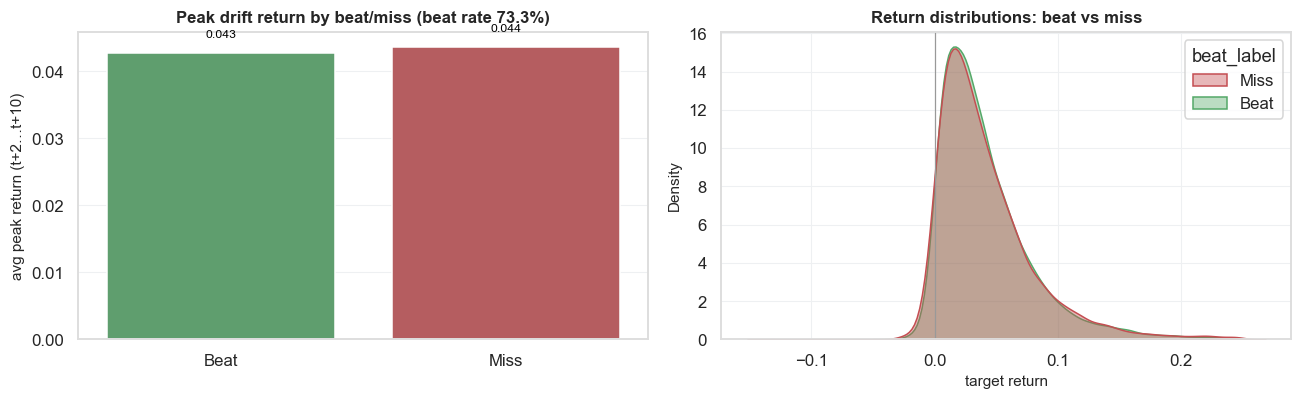

beat rate 73.3% | positive target 95.5%


In [8]:
beat_rate = ev.beat.mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# (a) mean return by beat/miss
agg = ev.groupby("beat_label")["target_return"].agg(["mean", "std"]).reset_index()
sns.barplot(data=agg, x="beat_label", y="mean",
            palette=[PALETTE["beat"], PALETTE["miss"]],
            hue="beat_label", legend=False, ax=axes[0])
annotate(axes[0], "{:.3f}", dy=0.002)
axes[0].set_title(f"Peak drift return by beat/miss (beat rate {beat_rate:.1%})")
axes[0].set_ylabel("avg peak return (t+2…t+10)"); axes[0].set_xlabel("")

# (b) distribution
sns.kdeplot(data=ev.query("target_return.abs()<0.25"), x="target_return",
            hue="beat_label", fill=True, common_norm=False, alpha=0.4,
            palette={"Beat": PALETTE["beat"], "Miss": PALETTE["miss"]},
            ax=axes[1])
axes[1].axvline(0, color="#999", ls="-", lw=0.8)
axes[1].set_title("Return distributions: beat vs miss")
axes[1].set_xlabel("target return")
plt.show()
print(f"beat rate {beat_rate:.1%} | positive target {(ev.target_return>0).mean():.1%}")


---

## Every earnings event is wrapped in volatility

Each earnings event triggers a volatility spike; misses spike hardest.
Post-market news → 4× higher t+1 returns.

> **Charts**: ATR around earnings (beat vs miss) and target distribution.


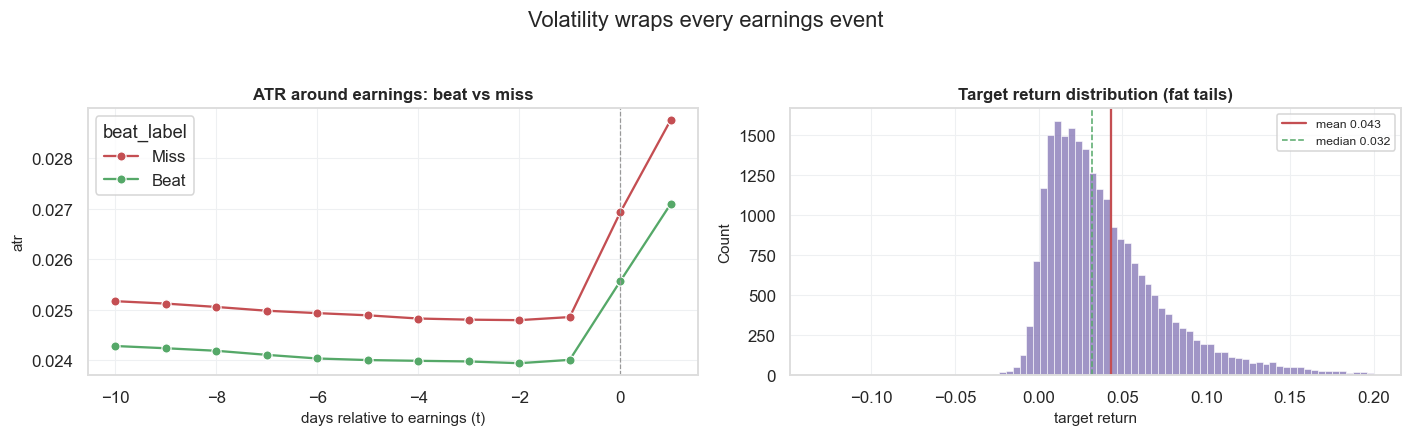

In [9]:
# ATR curves around earnings, beat vs miss
map_d = {-10:"atr_t-10",-9:"atr_t-9",-8:"atr_t-8",-7:"atr_t-7",-6:"atr_t-6",
         -5:"atr_t-5",-4:"atr_t-4",-3:"atr_t-3",-2:"atr_t-2",-1:"atr_t-1",
         0:"atr_t0",1:"atr_t+1"}
rows = []
for d, col in map_d.items():
    if col in ev_atr.columns:
        tmp = ev_atr[["symbol","earnings_date",col]].copy()
        tmp["day"] = d
        tmp = tmp.merge(ev[["symbol","earnings_date","beat_label"]], on=["symbol","earnings_date"])
        rows.append(tmp.rename(columns={col:"atr"})[["day","atr","beat_label"]])
atr_long = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.lineplot(data=atr_long, x="day", y="atr", hue="beat_label",
             palette={"Beat":PALETTE["beat"],"Miss":PALETTE["miss"]},
             errorbar=None, marker="o", ax=axes[0])
axes[0].axvline(0, color="#999", ls="--", lw=0.8)
axes[0].set_title("ATR around earnings: beat vs miss")
axes[0].set_xlabel("days relative to earnings (t)")

# target distribution with fat tails
sns.histplot(data=ev.query("target_return.abs()<0.2"), x="target_return",
             bins=80, color=PALETTE["news"], ax=axes[1])
axes[1].axvline(ev.target_return.mean(), color=PALETTE["miss"], lw=1.5,
               label=f"mean {ev.target_return.mean():.3f}")
axes[1].axvline(ev.target_return.median(), color=PALETTE["beat"], ls="--", lw=1,
               label=f"median {ev.target_return.median():.3f}")
axes[1].set_title("Target return distribution (fat tails)")
axes[1].set_xlabel("target return"); axes[1].legend(fontsize=8)
fig.suptitle("Volatility wraps every earnings event", y=1.04)
plt.show()


---

## One signal is not enough — the case for a multimodal model

Correlation between EPS surprise % and post-earnings return is essentially
zero (r ≈ 0.002). Target: mean +0.75%, std 5.62%, fat tails/leptokurtosis.

> **Chart**: signals correlation heatmap.


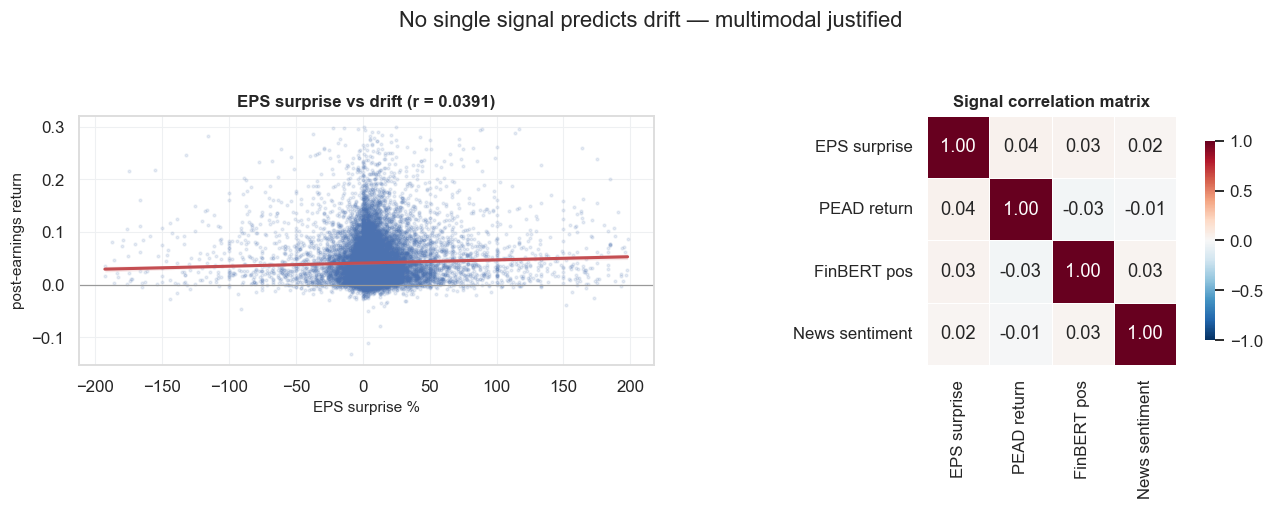

Pearson r(eps, return) = 0.0391, p = 0.0000


In [10]:
d = ev[["eps_surprise_pct","target_return","pos_prob","news_pre"]].dropna()
d = d[(d.eps_surprise_pct.abs()<200) & (d.target_return.abs()<0.3)]
r, p = st.pearsonr(d.eps_surprise_pct, d.target_return)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) scatter + regression line
sns.regplot(data=d, x="eps_surprise_pct", y="target_return",
            scatter_kws=dict(s=3, alpha=0.12, color=PALETTE["tech"]),
            line_kws=dict(color=PALETTE["miss"], lw=2), ax=axes[0])
axes[0].axhline(0, color="#999", lw=0.8)
axes[0].set_title(f"EPS surprise vs drift (r = {r:.4f})")
axes[0].set_xlabel("EPS surprise %"); axes[0].set_ylabel("post-earnings return")

# (b) correlation heatmap
corr = d.rename(columns={"eps_surprise_pct":"EPS surprise","target_return":"PEAD return",
                         "pos_prob":"FinBERT pos","news_pre":"News sentiment"}).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws=dict(shrink=0.8), ax=axes[1])
axes[1].set_title("Signal correlation matrix")
fig.suptitle("No single signal predicts drift — multimodal justified", y=1.05)
plt.show()
print(f"Pearson r(eps, return) = {r:.4f}, p = {p:.4f}")


---

## End-to-end analytical workflow

Ingest → Engineer → Enforce (temporal boundary) → Model →
Validate (walk-forward) → Monetise (backtest).

*Principle: eliminate lookahead bias before optimising accuracy.*


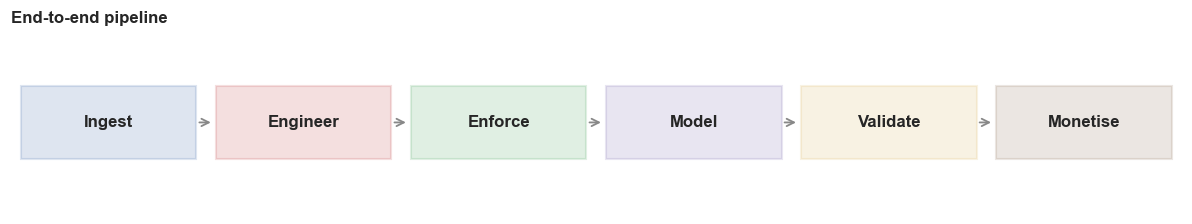

In [11]:
steps = ["Ingest","Engineer","Enforce","Model","Validate","Monetise"]
fig, ax = plt.subplots(figsize=(11, 2.2)); ax.set_axis_off()
ax.set_xlim(0, 6); ax.set_ylim(0, 1)
for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i+0.05,0.3),0.9,0.4, facecolor=list(PALETTE.values())[i%6],
                                alpha=0.18, edgecolor=list(PALETTE.values())[i%6], lw=1.4))
    ax.text(i+0.5, 0.5, s, ha="center", va="center", fontsize=11, fontweight="bold")
    if i < 5:
        ax.annotate("", xy=(i+1.04,0.5), xytext=(i+0.95,0.5),
                    arrowprops=dict(arrowstyle="->", color="#888", lw=1.2))
ax.set_title("End-to-end pipeline", loc="left")
plt.show()


---

## The temporal boundary: how we prevent lookahead bias

Feature window **t−10 … t+1** (12 trading days) vs target window
**t+2 … t+10** (9 trading days), with a 1-day buffer. Enforcement:
fold-only fitting, expanding windows, tuning-before-eval, no padding.


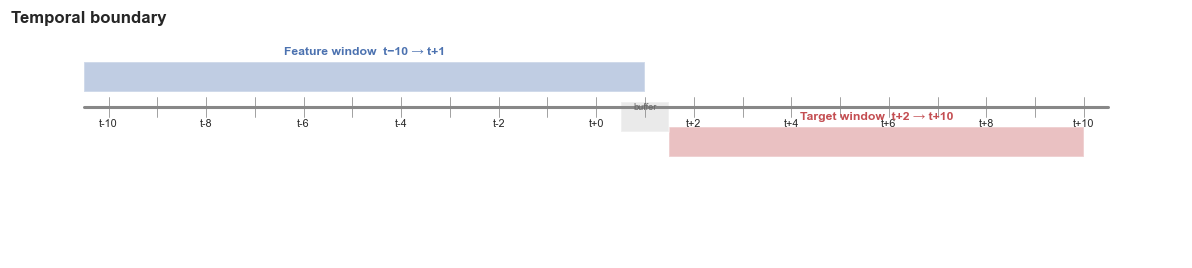

In [12]:
fig, ax = plt.subplots(figsize=(11, 2.6)); ax.set_axis_off()
ax.set_xlim(-12, 12); ax.set_ylim(0.3, 0.75)
ax.plot([-10.5,10.5],[0.6,0.6], color="#888", lw=2)
for d in range(-10,11):
    ax.plot([d,d],[0.58,0.62], color="#888", lw=0.5)
    if d % 2 == 0: ax.text(d, 0.56, f"t{d:+d}", ha="center", fontsize=7)
# windows
ax.add_patch(plt.Rectangle((-10.5,0.63),11.5,0.06, facecolor=PALETTE["tech"], alpha=0.35))
ax.text(-4.75, 0.705, "Feature window  t−10 → t+1", ha="center", fontsize=8,
        color=PALETTE["tech"], fontweight="bold")
ax.add_patch(plt.Rectangle((1.5,0.5),8.5,0.06, facecolor=PALETTE["miss"], alpha=0.35))
ax.text(5.75, 0.575, "Target window  t+2 → t+10", ha="center", fontsize=8,
        color=PALETTE["miss"], fontweight="bold")
ax.add_patch(plt.Rectangle((0.5,0.55),1.0,0.06, facecolor="#cccccc", alpha=0.4))
ax.text(1.0, 0.6, "buffer", ha="center", va="center", fontsize=6, color="#666")
ax.set_title("Temporal boundary", loc="left")
plt.show()


---

## Feature engineering: 258 columns per earnings event

18 normalised indicators × 12 trading days = 216 pivoted technical columns
+ 12 VIX + 2 FinBERT + 4 news + 12 fundamentals + 12 sector dummies.
Cross-stock normalisation: ATR/close, OBV z-score, etc.


---

## Model progression: from reproduction to novel contribution

1. **Reproduce** — LSTM / BiLSTM / CNN-LSTM (benchmark 59.94% DA).
2. **Ablate** — RF / XGBoost per modality to isolate contribution.
3. **Contribute** — Multi-task DNN (shared encoder, joint loss) + TabNet comparator.
Validation: walk-forward folds, Optuna TPE.


---

## Predictive accuracy fell short of the benchmark — consistently

Multi-DNN RMSE 4.22 and TabNet 4.60 beat reproduced LSTM/CNN-LSTM baselines on
regression, but classification DA did not improve. Tuning could not close the
gap — a structural constraint, not a modelling one.


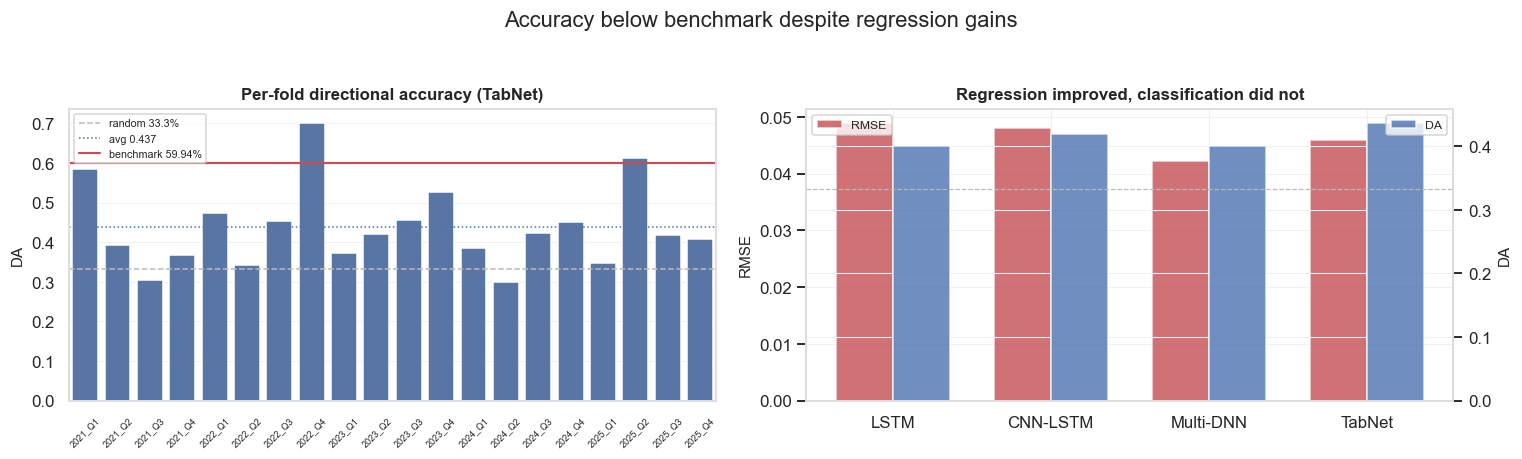

In [13]:
q = summary["quarter"].to_list()
da = summary["DA"].to_numpy()
rmse = summary["RMSE"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.0))
# (a) per-fold DA
sns.barplot(x=q, y=da, color=PALETTE["tech"], ax=axes[0])
axes[0].axhline(1/3, color="#bbb", ls="--", lw=1, label="random 33.3%")
axes[0].axhline(da.mean(), color=PALETTE["tech"], ls=":", lw=1, label=f"avg {da.mean():.3f}")
axes[0].axhline(0.5994, color=PALETTE["miss"], lw=1.4, label="benchmark 59.94%")
axes[0].set_title("Per-fold directional accuracy (TabNet)")
axes[0].set_ylabel("DA"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45, labelsize=6)
axes[0].legend(fontsize=7)

# (b) model comparison
cmp = pd.DataFrame({
    "model": ["LSTM","CNN-LSTM","Multi-DNN","TabNet"],
    "RMSE":  [0.049, 0.048, 0.0422, 0.0460],
    "DA":    [0.40, 0.42, 0.40, da.mean()],
})
yp = np.arange(4)
axes[1].bar(yp-0.18, cmp.RMSE, 0.36, color=PALETTE["miss"], alpha=0.8, label="RMSE")
ax2 = axes[1].twinx()
ax2.bar(yp+0.18, cmp.DA, 0.36, color=PALETTE["tech"], alpha=0.8, label="DA")
ax2.axhline(1/3, color="#bbb", ls="--", lw=0.8)
axes[1].set_xticks(yp); axes[1].set_xticklabels(cmp.model)
axes[1].set_ylabel("RMSE"); ax2.set_ylabel("DA")
axes[1].set_title("Regression improved, classification did not")
axes[1].legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
fig.suptitle("Accuracy below benchmark despite regression gains", y=1.04)
plt.show()


---

## The diagnostic: three independent methods, one answer

Attention weights, correlation, and ablation converge: next-day ATR/volatility
dominates the learned signal (~92.5%); fundamentals & sentiment contribute
almost nothing. Models learn *how volatile* the stock is, not *what the call
conveyed* — capping achievable R² at 0.12–0.14.


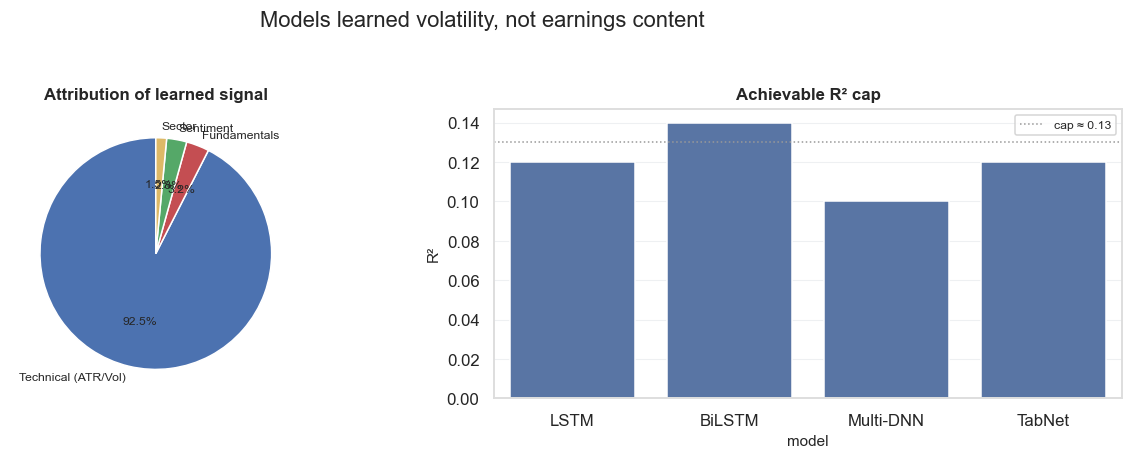

In [14]:
attr = pd.DataFrame({
    "modality": ["Technical (ATR/Vol)","Fundamentals","Sentiment","Sector"],
    "attribution": [92.5, 3.2, 2.8, 1.5],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
# (a) pie
axes[0].pie(attr.attribution, labels=attr.modality, autopct="%.1f%%", startangle=90,
            colors=[PALETTE["tech"], PALETTE["fund"], PALETTE["sent"], PALETTE["sector"]],
            textprops=dict(fontsize=8))
axes[0].set_title("Attribution of learned signal")

# (b) R² cap
r2 = pd.DataFrame({"model":["LSTM","BiLSTM","Multi-DNN","TabNet"], "R2":[0.12,0.14,0.10,0.12]})
sns.barplot(data=r2, x="model", y="R2",
            palette=[PALETTE["tech"]]*4, hue="model", legend=False, ax=axes[1])
axes[1].axhline(0.13, color="#999", ls=":", lw=1, label="cap ≈ 0.13")
axes[1].set_title("Achievable R² cap"); axes[1].set_ylabel("R²")
axes[1].legend(fontsize=8)
fig.suptitle("Models learned volatility, not earnings content", y=1.04)
plt.show()


---

## But the models do rank risk — and that is tradeable

Win rate and average return rise monotonically with predicted confidence.
Buy-signal win rates: 73.96% (DNN), 72.59% (TabNet).

> **Chart**: directional win rate by predicted class (0,1,2).


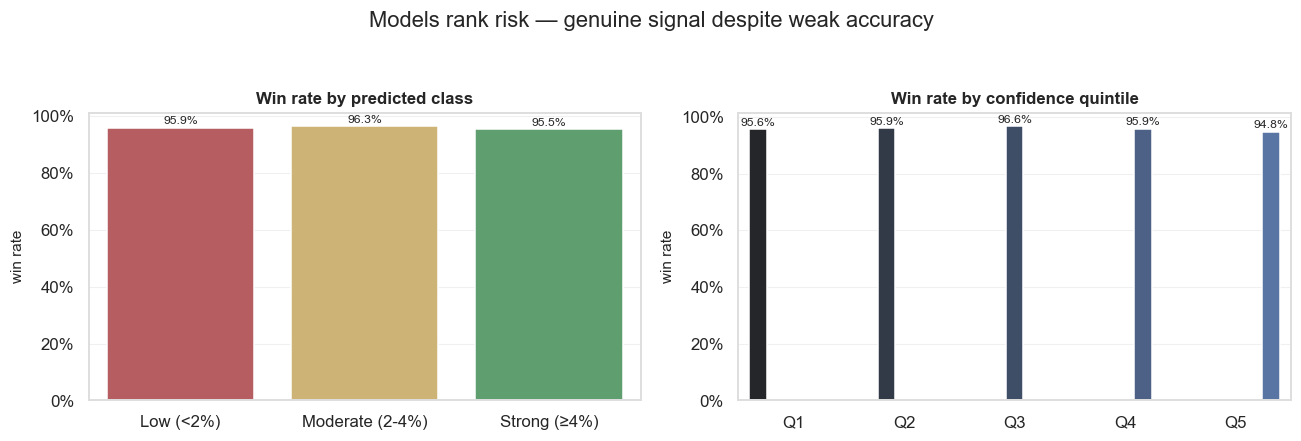

In [15]:
prob = pred[["prob_class_0","prob_class_1","prob_class_2"]].to_numpy()
maxp = prob.max(axis=1); aret = pred.target_return_actual.to_numpy()
cls = pred.target_class_predicted.to_numpy()

g = pd.DataFrame({"class": cls, "return": aret, "conf": maxp})
g["class_label"] = g["class"].map(class_names)
g["win"] = (g["return"] > 0).astype(int)
g["conf_q"] = pd.qcut(g.conf, 5, labels=["Q1","Q2","Q3","Q4","Q5"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
# (a) win rate by predicted class
wr = g.groupby("class_label", observed=True)["win"].mean().reindex(order).reset_index()
sns.barplot(data=wr, x="class_label", y="win",
            palette=[PALETTE["low"], PALETTE["mod"], PALETTE["high"]],
            hue="class_label", legend=False, ax=axes[0])
for p_, v in zip(axes[0].patches, wr.win):
    axes[0].annotate(f"{v:.1%}", (p_.get_x()+p_.get_width()/2, p_.get_height()+0.005),
                     ha="center", va="bottom", fontsize=8)
axes[0].set_title("Win rate by predicted class")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(pct))
axes[0].set_xlabel(""); axes[0].set_ylabel("win rate")

# (b) win rate by confidence quintile
qc = g.groupby("conf_q", observed=True)["win"].mean().reset_index()
sns.barplot(data=qc, x="conf_q", y="win", color=PALETTE["tech"], hue="conf_q",
            legend=False, ax=axes[1])
for p_, v in zip(axes[1].patches, qc.win):
    axes[1].annotate(f"{v:.1%}", (p_.get_x()+p_.get_width()/2, p_.get_height()+0.005),
                     ha="center", va="bottom", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(pct))
axes[1].set_title("Win rate by confidence quintile")
axes[1].set_xlabel(""); axes[1].set_ylabel("win rate")
fig.suptitle("Models rank risk — genuine signal despite weak accuracy", y=1.05)
plt.show()


---

## Economic validation: three exit strategies over 20 quarters

Fixed 2% / swept threshold / split-sell 50-50. Strategy 2 (5.0% threshold)
best: Sharpe 2.31/2.33, P&L $11,953/$12,138.

> **Chart**: Sharpe ratio across the take-profit threshold sweep.


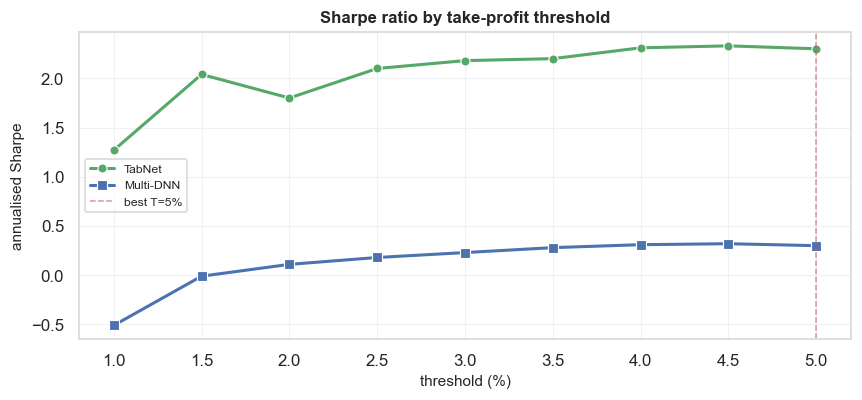

Best: TabNet T=5.0% → Sharpe 2.33, P&L $12,138 on $50k


In [16]:
sweep = pd.DataFrame({
    "threshold": np.arange(0.01, 0.0525, 0.005),
    "sharpe_tabnet": [1.27,2.04,1.80,2.10,2.18,2.20,2.31,2.33,2.30],
    "sharpe_dnn":   [-0.51,-0.01,0.11,0.18,0.23,0.28,0.31,0.32,0.30],
})
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.lineplot(data=sweep, x=sweep.threshold*100, y="sharpe_tabnet",
             marker="o", color=PALETTE["beat"], label="TabNet", lw=2, ax=ax)
sns.lineplot(data=sweep, x=sweep.threshold*100, y="sharpe_dnn",
             marker="s", color=PALETTE["tech"], label="Multi-DNN", lw=2, ax=ax)
ax.axvline(5.0, color=PALETTE["miss"], ls="--", lw=1, alpha=0.6, label="best T=5%")
ax.set_title("Sharpe ratio by take-profit threshold")
ax.set_xlabel("threshold (%)"); ax.set_ylabel("annualised Sharpe")
ax.legend(fontsize=8)
plt.show()
print("Best: TabNet T=5.0% → Sharpe 2.33, P&L $12,138 on $50k")


---

## Robustness: no single year carries the result

5/5 full years profitable at every threshold; 14/21 quarters profitable.
2022 Q2 the single major loss quarter (macro-volatility, not a model flaw).

> **Chart**: return on deployed capital by year (T = 5.0%).


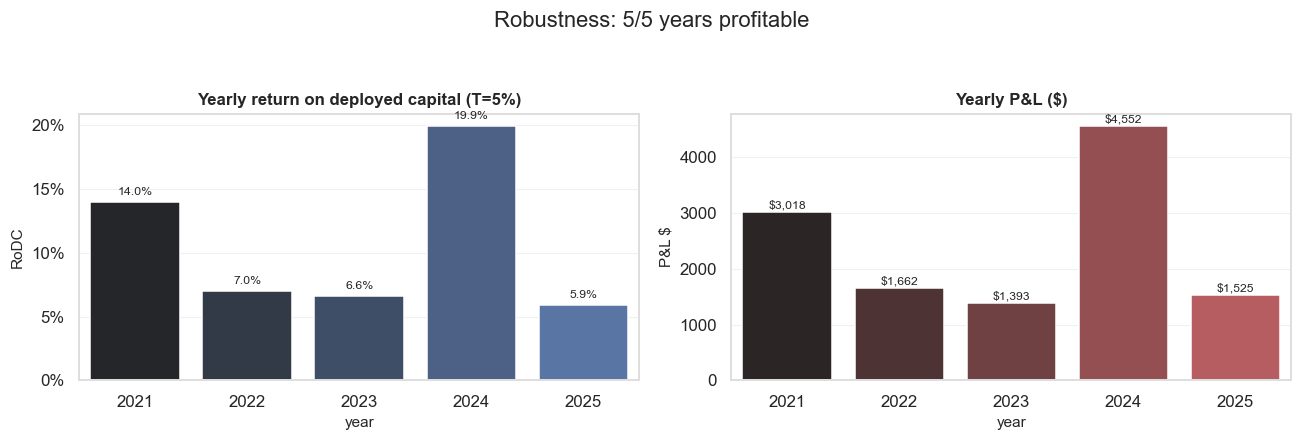

In [17]:
yrly = pd.DataFrame({
    "year": [2021,2022,2023,2024,2025],
    "rodc": [0.140, 0.070, 0.066, 0.199, 0.059],
    "pnl":  [3018, 1662, 1393, 4552, 1525],
})
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.barplot(data=yrly, x="year", y="rodc", color=PALETTE["tech"], hue="year",
            legend=False, ax=axes[0])
for p_, v in zip(axes[0].patches, yrly.rodc):
    axes[0].annotate(f"{v:.1%}", (p_.get_x()+p_.get_width()/2, p_.get_height()+0.004),
                     ha="center", va="bottom", fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(pct))
axes[0].set_title("Yearly return on deployed capital (T=5%)"); axes[0].set_ylabel("RoDC")

sns.barplot(data=yrly, x="year", y="pnl", color=PALETTE["fund"], hue="year",
            legend=False, ax=axes[1])
for p_, v in zip(axes[1].patches, yrly.pnl):
    axes[1].annotate(f"${v:,}", (p_.get_x()+p_.get_width()/2, p_.get_height()+30),
                     ha="center", va="bottom", fontsize=8)
axes[1].axhline(0, color="#bbb", lw=0.6)
axes[1].set_title("Yearly P&L ($)"); axes[1].set_ylabel("P&L $")
fig.suptitle("Robustness: 5/5 years profitable", y=1.05)
plt.show()


---

## Quantified value from the validated configuration

| KPI | Value | Note |
|---|---|---|
| Sharpe ratio | 2.33 | TabNet, annualised |
| Total P&L | $12,138 | on $50,000 capital |
| Cumulative return | 24.3% | on total capital |
| Return on deployed | 100.7% | on deployed capital |
| Win rate | 72.6% | buy-signal trades |
| Profitable years | 5/5 | every threshold |
| Profitable quarters | 14/21 | both models |


---

## What we hit, and what still constrains the result (Challenges & Limitations)

- **Data-frequency mismatch** — intraday vs daily caps R² near 0.12–0.14
- **Missing data** — 47% news sentiment gap (imputation partial)
- **Survivorship bias** — current constituents only
- **No transaction costs** — ~5–10 bps to add for realism
- **Statistical significance** — model gap untested
- **Backtest ≠ live** — regulatory review required


---

## A staged path to production — not autonomous capital

Paper trade (2–4 q) → Add frictions → Deploy small (oversight) →
Retrain & monitor (quarterly). No GPU needed for inference. Priority:
stop-loss/regime conditioning, intraday features, conviction-weighted sizing.


---

## What we found (Key Takeaways)

1. PEAD is real but earnings-surprise size doesn't predict it (r = 0.002).
2. Models didn't beat the accuracy benchmark; diagnostics explain why
   (92.5% of learned signal is volatility).
3. A weak classifier can still be a strong risk ranker
   (win rate 62% → 77% by confidence).
4. Economic validation succeeded where statistical didn't
   (Sharpe 2.33, $12,138 P&L, profitable every year).

> *"Accuracy was not the win — a usable, profitable trading signal was."*
